In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns



# Pre-processing the data

In [2]:
# Read the data

# creditTestData = pd.read_csv('CreditData_dataTest.csv')
# # creditTestData.head()
# creditTestData.shape # (101503, 12)

# test data holds no values in SeriousDlqin2yrs. Using only provided taining set for model data
creditTrainingData = pd.read_csv('CreditData_dataTraining.csv')
# creditTrainingData.head()
creditTrainingData.shape # (150000, 12)


(150000, 12)

In [ ]:
# merge testing/training

# combined_credit_data = pd.concat([creditTrainingData, creditTestData], axis=0, ignore_index=True)
# combined_credit_data.head()

In [ ]:
# # since combining training and test data, reset for sequential index
# combined_credit_data = combined_credit_data.reset_index(drop=True)
# combined_credit_data.shape # (251503, 12)

In [19]:
# drop all rows where null cell

print("\nNumber of NA values in each column:")
print(creditTrainingData.isna().sum())

cleaned_creditData = creditTrainingData.dropna()
# cleaned_creditData.shape # (120269, 12)
cleaned_creditData.head()

# # To see what percentage of data was dropped
# original_rows = creditTrainingData.shape[0]
# remaining_rows = cleaned_creditData.shape[0]
# dropped_percentage = ((original_rows - remaining_rows) / original_rows) * 100

# print(f"\nDropped {original_rows - remaining_rows} rows ({dropped_percentage:.2f}% of original data)")


Number of NA values in each column:
Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Exploaratory Data Analysis

In [14]:
cleaned_creditData.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,120269.000000,120269.000000,120269.000000,120269.000000,120269.000000,120269.000000,1.202690e+05,120269.000000,120269.000000,120269.000000,120269.000000,120269.000000
mean,75026.012514,0.069486,5.899873,51.289792,0.381769,26.598777,6.670221e+03,8.758475,0.211925,1.054519,0.187829,0.851832
std,43286.029117,0.254280,257.040685,14.426684,3.499234,424.446457,1.438467e+04,5.172835,3.465276,1.149273,3.447901,1.148391
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37678.000000,0.000000,0.035084,40.000000,0.000000,0.143388,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,74969.000000,0.000000,0.177282,51.000000,0.000000,0.296023,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112494.000000,0.000000,0.579428,61.000000,0.000000,0.482559,8.249000e+03,11.000000,0.000000,2.000000,0.000000,2.000000
max,150000.000000,1.000000,50708.000000,103.000000,98.000000,61106.500000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [60]:

X = cleaned_creditData.drop('SeriousDlqin2yrs', axis=1)  # Features
y = cleaned_creditData['SeriousDlqin2yrs']  # Target variable

# Create new train/test split (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=122)


# What is the probability of a given individual defaulting on their loan within the next two years?

In [62]:
# Calculate class weights
# w/o weighting, model predicted "no default" for almost everyone
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))


In [64]:
model = LogisticRegression(class_weight=class_weight_dict, random_state=122)
model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight={0: 0.5368900941922236, 1: 7.276887006504311},
                   random_state=122)

In [66]:
# Get probability predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of default

In [68]:
# Get binary predictions
y_pred = model.predict(X_test)

In [70]:
# Print performance metrics
print("\nModel Performance:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))



Model Performance:
              precision    recall  f1-score   support

           0       0.96      0.74      0.83     22308
           1       0.15      0.61      0.25      1746

    accuracy                           0.73     24054
   macro avg       0.56      0.67      0.54     24054
weighted avg       0.90      0.73      0.79     24054


ROC-AUC Score: 0.7360801995020868


# Which financial indicators are the strongest predictors of loan default?


In [81]:
# Dictionary mapping column names to descriptions
feature_descriptions = {
    'RevolvingUtilizationOfUnsecuredLines': 'Credit Utilization Rate',
    'age': 'Age of Borrower',
    'NumberOfTime30-59DaysPastDueNotWorse': '30-59 Days Past Due Count',
    'DebtRatio': 'Debt-to-Income Ratio',
    'MonthlyIncome': 'Monthly Income',
    'NumberOfOpenCreditLinesAndLoans': 'Open Credit Lines & Loans',
    'NumberOfTimes90DaysLate': '90+ Days Late Count',
    'NumberRealEstateLoansOrLines': 'Real Estate Loans Count',
    'NumberOfTime60-89DaysPastDueNotWorse': '60-89 Days Past Due Count',
    'NumberOfDependents': 'Number of Dependents'
}

In [87]:
# Create a pipeline with scaling and logistic regression
# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

# Fit the pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [99]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': np.abs(pipeline.named_steps['classifier'].coef_[0]),
    'coefficient': pipeline.named_steps['classifier'].coef_[0]
})

# Sort by absolute importance
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Print detailed feature importance
print("Feature Importance Analysis Ranked by absolute importance:")
print(feature_importance)

Feature Importance Analysis Ranked by absolute importance:
                                 feature  importance  coefficient
7                NumberOfTimes90DaysLate    2.173123     2.173123
3   NumberOfTime30-59DaysPastDueNotWorse    2.040611     2.040611
9   NumberOfTime60-89DaysPastDueNotWorse    0.592906     0.592906
5                          MonthlyIncome    0.483780    -0.483780
2                                    age    0.383442    -0.383442
8           NumberRealEstateLoansOrLines    0.106632     0.106632
10                    NumberOfDependents    0.078824     0.078824
4                              DebtRatio    0.032758    -0.032758
1   RevolvingUtilizationOfUnsecuredLines    0.016788    -0.016788
6        NumberOfOpenCreditLinesAndLoans    0.016105     0.016105
0                             Unnamed: 0    0.003497     0.003497


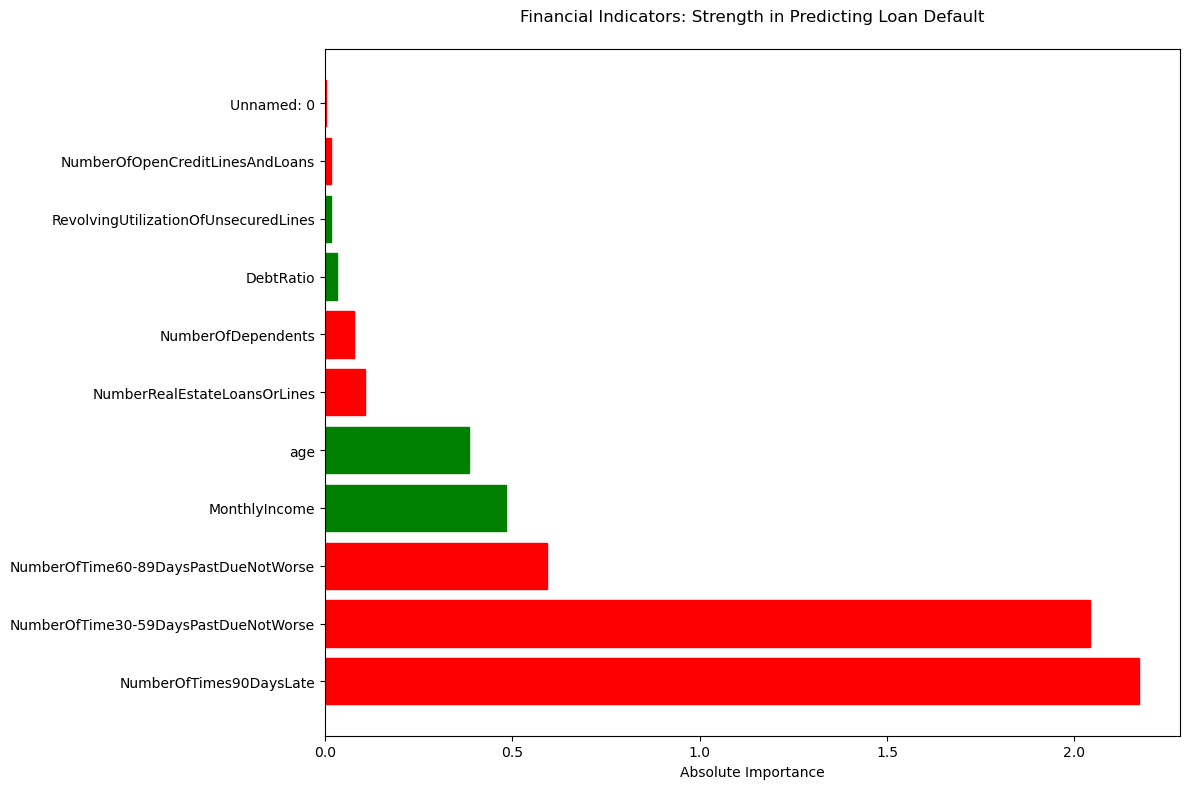

In [93]:
# visualization
plt.figure(figsize=(12, 8))
bars = plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('Financial Indicators: Strength in Predicting Loan Default', pad=20)
plt.xlabel('Absolute Importance')

# Color the bars based on coefficient sign
for i, coef in enumerate(feature_importance['coefficient']):
    if coef > 0:
        bars[i].set_color('red')    # Increases default risk
    else:
        bars[i].set_color('green')  # Decreases default risk

plt.tight_layout()
plt.show()

In [97]:
# analysis
print("\nDETAILED ANALYSIS OF FINANCIAL INDICATORS:")
print("\nRanked by importance (strongest to weakest predictors):")
print("=" * 80)
for _, row in feature_importance.iterrows():
    direction = "INCREASES" if row['coefficient'] > 0 else "DECREASES"
    print(f"\n{row['feature']}:")
    print(f"- Relative Importance: {row['importance']:.4f}")
    print(f"- Direction: {direction} default risk")


DETAILED ANALYSIS OF FINANCIAL INDICATORS:

Ranked by importance (strongest to weakest predictors):

NumberOfTimes90DaysLate:
- Relative Importance: 2.1731
- Direction: INCREASES default risk

NumberOfTime30-59DaysPastDueNotWorse:
- Relative Importance: 2.0406
- Direction: INCREASES default risk

NumberOfTime60-89DaysPastDueNotWorse:
- Relative Importance: 0.5929
- Direction: INCREASES default risk

MonthlyIncome:
- Relative Importance: 0.4838
- Direction: DECREASES default risk

age:
- Relative Importance: 0.3834
- Direction: DECREASES default risk

NumberRealEstateLoansOrLines:
- Relative Importance: 0.1066
- Direction: INCREASES default risk

NumberOfDependents:
- Relative Importance: 0.0788
- Direction: INCREASES default risk

DebtRatio:
- Relative Importance: 0.0328
- Direction: DECREASES default risk

RevolvingUtilizationOfUnsecuredLines:
- Relative Importance: 0.0168
- Direction: DECREASES default risk

NumberOfOpenCreditLinesAndLoans:
- Relative Importance: 0.0161
- Direction:

# Can we identify specific customer segments with a high likelihood of default?


In [168]:
# create a risk score based on our most significant predictors
def create_risk_profile(data):
    # Create a copy of relevant features
    risk_data = data.copy()
    
    # Calculate risk score based on our previous feature importance
    risk_data['risk_score'] = (
        2.173 * risk_data['NumberOfTimes90DaysLate'] +
        2.041 * risk_data['NumberOfTime30-59DaysPastDueNotWorse'] +
        0.593 * risk_data['NumberOfTime60-89DaysPastDueNotWorse'] -
        0.484 * risk_data['MonthlyIncome'].fillna(risk_data['MonthlyIncome'].mean()) / risk_data['MonthlyIncome'].std() -
        0.383 * risk_data['age']
    )
    
    return risk_data


In [169]:
# use clustering to idenitfy customer segments 
def prepare_clustering_data(data):
    cluster_features = [
        'age',
        'MonthlyIncome',
        'NumberOfTimes90DaysLate',
        'NumberOfTime30-59DaysPastDueNotWorse',
        'NumberOfTime60-89DaysPastDueNotWorse',
        'DebtRatio',
        'RevolvingUtilizationOfUnsecuredLines'
    ]
# Create copy of selected features
    X = data[cluster_features].copy()
    
    # Handle missing values
    X['MonthlyIncome'] = X['MonthlyIncome'].fillna(X['MonthlyIncome'].mean())
    
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return pd.DataFrame(X_scaled, columns=cluster_features)

In [170]:
# Create the analysis
def analyze_segments(data, clusters, risk_data, y_data):
    # Combine cluster assignments with original data and target
    segmented_data = data.copy()
    segmented_data['Cluster'] = clusters
    segmented_data['risk_score'] = risk_data['risk_score']
    segmented_data['SeriousDlqin2yrs'] = y_data  # Add target variable
    
    # Analyze each cluster
    cluster_analysis = []
    for cluster in range(len(segmented_data['Cluster'].unique())):
        cluster_data = segmented_data[segmented_data['Cluster'] == cluster]
        
        analysis = {
            'Cluster': cluster,
            'Size': len(cluster_data),
            'Default_Rate': cluster_data['SeriousDlqin2yrs'].mean() * 100,
            'Avg_Age': cluster_data['age'].mean(),
            'Avg_Income': cluster_data['MonthlyIncome'].mean(),
            'Avg_DebtRatio': cluster_data['DebtRatio'].mean(),
            'Avg_Risk_Score': cluster_data['risk_score'].mean(),
            '90DaysLate_Rate': cluster_data['NumberOfTimes90DaysLate'].mean(),
            'Credit_Utilization': cluster_data['RevolvingUtilizationOfUnsecuredLines'].mean()
        }
        cluster_analysis.append(analysis)
    
    return pd.DataFrame(cluster_analysis)


In [175]:
# Run the analysis
# Create risk profiles
risk_data = create_risk_profile(X_train)

# Prepare data for clustering
X_cluster = prepare_clustering_data(X_train)

# Perform clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_cluster)

# Analyze segments
segment_analysis = analyze_segments(X_train, clusters, risk_data, y_train)

# Print segment analysis
print("\nCustomer Segment Analysis:")
print("=" * 80)
print(segment_analysis.round(2))



Customer Segment Analysis:
   Cluster   Size  Default_Rate  Avg_Age  Avg_Income  Avg_DebtRatio  \
0        0  43718          4.33    64.21     7108.79          15.63   
1        1    125         55.20    35.63     2616.31           0.01   
2        2  52360          8.88    40.52     6124.57          34.81   
3        3     12          0.00    57.42  1068865.42           0.00   

   Avg_Risk_Score  90DaysLate_Rate  Credit_Utilization  
0          -24.22             0.06                2.80  
1          457.05            97.94                1.00  
2          -14.78             0.12                9.40  
3          -54.47             0.00                0.14  


Text(0.5, 1.0, 'Customer Segments by Age and Income')

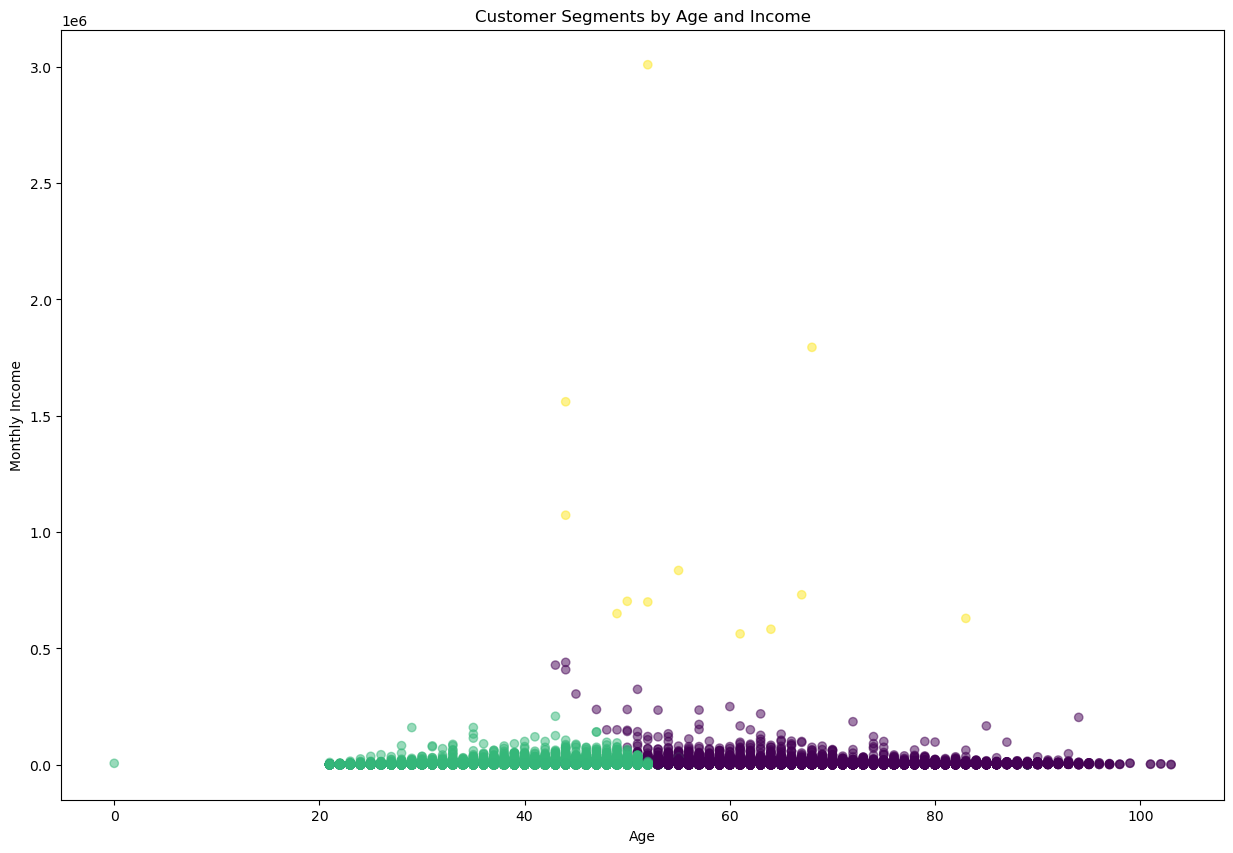

In [177]:
# Visualize segments
plt.figure(figsize=(15, 10))

# Create scatter plot
# plt.subplot(2, 2, 1)
plt.scatter(X_train['age'], X_train['MonthlyIncome'], c=clusters, cmap='viridis', alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Monthly Income')
plt.title('Customer Segments by Age and Income')

Text(0.5, 1.0, 'Risk Score Distribution by Cluster')

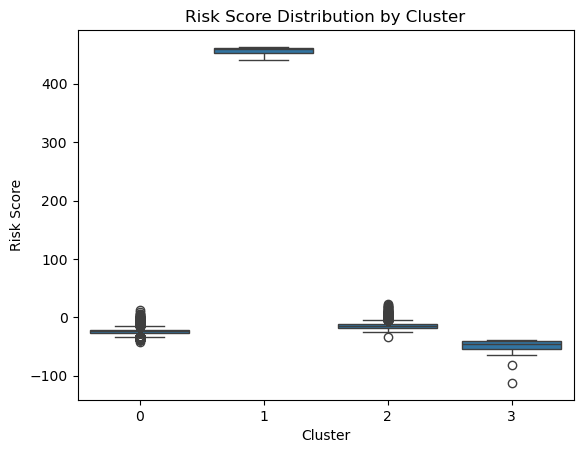

In [178]:
# Create risk score distribution by cluster
# plt.subplot(2, 2, 2)
sns.boxplot(x=clusters, y=risk_data['risk_score'])
plt.xlabel('Cluster')
plt.ylabel('Risk Score')
plt.title('Risk Score Distribution by Cluster')

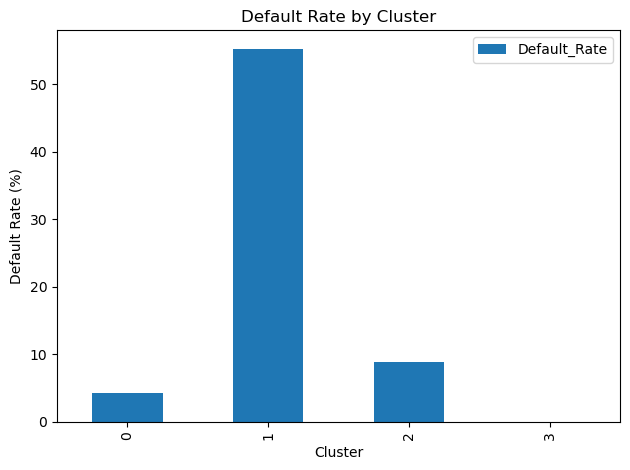

In [179]:
# Create default rate by cluster
default_rates = segment_analysis[['Cluster', 'Default_Rate']].set_index('Cluster')
default_rates.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Default Rate (%)')
plt.title('Default Rate by Cluster')

plt.tight_layout()
plt.show()

In [180]:
# Print detailed segment profiles
print("\nDetailed Segment Profiles:")
print("=" * 80)
for idx, row in segment_analysis.iterrows():
    print(f"\nCluster {int(row['Cluster'])}:")
    print(f"Size: {int(row['Size'])} customers ({row['Size']/len(X_train)*100:.1f}% of total)")
    print(f"Default Rate: {row['Default_Rate']:.1f}%")
    print(f"Average Profile:")
    print(f"- Age: {row['Avg_Age']:.1f} years")
    print(f"- Monthly Income: ${row['Avg_Income']:.2f}")
    print(f"- Debt Ratio: {row['Avg_DebtRatio']:.2f}")
    print(f"- 90 Days Late Rate: {row['90DaysLate_Rate']:.2f}")
    print(f"- Credit Utilization: {row['Credit_Utilization']:.2f}")



Detailed Segment Profiles:

Cluster 0:
Size: 43718 customers (45.4% of total)
Default Rate: 4.3%
Average Profile:
- Age: 64.2 years
- Monthly Income: $7108.79
- Debt Ratio: 15.63
- 90 Days Late Rate: 0.06
- Credit Utilization: 2.80

Cluster 1:
Size: 125 customers (0.1% of total)
Default Rate: 55.2%
Average Profile:
- Age: 35.6 years
- Monthly Income: $2616.31
- Debt Ratio: 0.01
- 90 Days Late Rate: 97.94
- Credit Utilization: 1.00

Cluster 2:
Size: 52360 customers (54.4% of total)
Default Rate: 8.9%
Average Profile:
- Age: 40.5 years
- Monthly Income: $6124.57
- Debt Ratio: 34.81
- 90 Days Late Rate: 0.12
- Credit Utilization: 9.40

Cluster 3:
Size: 12 customers (0.0% of total)
Default Rate: 0.0%
Average Profile:
- Age: 57.4 years
- Monthly Income: $1068865.42
- Debt Ratio: 0.00
- 90 Days Late Rate: 0.00
- Credit Utilization: 0.14


# How do changes in a borrower's financial situation (e.g., increased monthly income or fewer open credit lines) impact their predicted default risk?


In [188]:
# use our logistic regression coefficients and feature importance results from earlier
feature_impacts = {
    'NumberOfTimes90DaysLate': 2.173,
    'NumberOfTime30-59DaysPastDueNotWorse': 2.041,
    'NumberOfTime60-89DaysPastDueNotWorse': 0.593,
    'MonthlyIncome': -0.484,  # Negative means it reduces default risk
    'age': -0.383,  # Negative means it reduces default risk
    'NumberRealEstateLoansOrLines': 0.107,
    'NumberOfDependents': 0.079,
    'DebtRatio': -0.033,
    'RevolvingUtilizationOfUnsecuredLines': -0.017,
    'NumberOfOpenCreditLinesAndLoans': 0.016
}


In [189]:
# function to show impact of changes
def calculate_risk_change(feature, current_value, new_value, coefficient):
    change = new_value - current_value
    risk_impact = change * coefficient
    direction = "decrease" if risk_impact < 0 else "increase"
    return abs(risk_impact), direction


In [190]:
# Example scenarios
print("Impact of Financial Changes on Default Risk")
print("=" * 50)

# Scenario 1: Income Change
income_current = 5000
income_new = 7000
impact, direction = calculate_risk_change('MonthlyIncome', 
                                       income_current, 
                                       income_new, 
                                       feature_impacts['MonthlyIncome'])
print(f"\nScenario 1: Monthly Income Change")
print(f"Change: ${income_current:,} → ${income_new:,}")
print(f"Impact: {impact:.3f} risk score {direction}")

# Scenario 2: Late Payments
print(f"\nScenario 2: Late Payment History")
print(f"Impact of one 30-59 day late payment: {feature_impacts['NumberOfTime30-59DaysPastDueNotWorse']:.3f} risk score increase")
print(f"Impact of one 90+ day late payment: {feature_impacts['NumberOfTimes90DaysLate']:.3f} risk score increase")

# Scenario 3: Credit Utilization
util_current = 0.80
util_new = 0.30
impact, direction = calculate_risk_change('RevolvingUtilizationOfUnsecuredLines', 
                                       util_current, 
                                       util_new, 
                                       feature_impacts['RevolvingUtilizationOfUnsecuredLines'])
print(f"\nScenario 3: Credit Utilization Change")
print(f"Change: {util_current*100:.0f}% → {util_new*100:.0f}%")
print(f"Impact: {impact:.3f} risk score {direction}")

Impact of Financial Changes on Default Risk

Scenario 1: Monthly Income Change
Change: $5,000 → $7,000
Impact: 968.000 risk score decrease

Scenario 2: Late Payment History
Impact of one 30-59 day late payment: 2.041 risk score increase
Impact of one 90+ day late payment: 2.173 risk score increase

Scenario 3: Credit Utilization Change
Change: 80% → 30%
Impact: 0.009 risk score increase


In [191]:
# Relative Impact Analysis
print("\nRelative Impact of Financial Changes")
print("=" * 50)
sorted_impacts = sorted(feature_impacts.items(), key=lambda x: abs(x[1]), reverse=True)
for feature, coefficient in sorted_impacts:
    direction = "increases" if coefficient > 0 else "decreases"
    print(f"{feature}: {abs(coefficient):.3f} ({direction} risk)")


Relative Impact of Financial Changes
NumberOfTimes90DaysLate: 2.173 (increases risk)
NumberOfTime30-59DaysPastDueNotWorse: 2.041 (increases risk)
NumberOfTime60-89DaysPastDueNotWorse: 0.593 (increases risk)
MonthlyIncome: 0.484 (decreases risk)
age: 0.383 (decreases risk)
NumberRealEstateLoansOrLines: 0.107 (increases risk)
NumberOfDependents: 0.079 (increases risk)
DebtRatio: 0.033 (decreases risk)
RevolvingUtilizationOfUnsecuredLines: 0.017 (decreases risk)
NumberOfOpenCreditLinesAndLoans: 0.016 (increases risk)


# What are the key differences in financial behavior and demographics between borrowers who default and those who do not?


In [198]:
# comparison demographics
def analyze_default_groups(X, y):
    # Combine features and target
    data = X.copy()
    data['Default'] = y
    
    # Calculate statistics for each group
    defaulters = data[data['Default'] == 1]
    non_defaulters = data[data['Default'] == 0]
    
    # Calculate statistics
    stats = pd.DataFrame({
        'Non-Defaulters (Mean)': non_defaulters.mean(),
        'Defaulters (Mean)': defaulters.mean(),
        'Non-Defaulters (Median)': non_defaulters.median(),
        'Defaulters (Median)': defaulters.median(),
    })
    
    # Add percentage difference
    stats['% Difference in Means'] = ((stats['Defaulters (Mean)'] - stats['Non-Defaulters (Mean)']) / stats['Non-Defaulters (Mean)'] * 100)
    
    return stats


In [200]:
comparison_stats = analyze_default_groups(X_train, y_train)

# Display results
print("Comparison Between Defaulters and Non-Defaulters")
print("=" * 80)
print(comparison_stats.round(2))

Comparison Between Defaulters and Non-Defaulters
                                      Non-Defaulters (Mean)  \
Unnamed: 0                                         74902.06   
RevolvingUtilizationOfUnsecuredLines                   6.59   
age                                                   51.68   
NumberOfTime30-59DaysPastDueNotWorse                   0.27   
DebtRatio                                             26.44   
MonthlyIncome                                       6779.47   
NumberOfOpenCreditLinesAndLoans                        8.79   
NumberOfTimes90DaysLate                                0.11   
NumberRealEstateLoansOrLines                           1.06   
NumberOfTime60-89DaysPastDueNotWorse                   0.10   
NumberOfDependents                                     0.84   
Default                                                0.00   

                                      Defaulters (Mean)  \
Unnamed: 0                                     75268.41   
RevolvingUtil

In [202]:
# Calculate the default rate for different age groups
def age_group_analysis(X, y):
    data = X.copy()
    data['Default'] = y
    data['AgeGroup'] = pd.cut(data['age'], bins=[0, 25, 35, 45, 55, 65, 100], 
                             labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])
    
    return data.groupby('AgeGroup')['Default'].agg(['count', 'mean', 'sum'])

In [206]:

age_analysis = age_group_analysis(X_train, y_train)
print("\nDefault Rates by Age Group")
print("=" * 80)
print(age_analysis)


Default Rates by Age Group
          count      mean   sum
AgeGroup                       
18-25      1936  0.101240   196
26-35     12741  0.106507  1357
36-45     20442  0.086195  1762
46-55     24316  0.076781  1867
56-65     20598  0.048014   989
65+       16175  0.027141   439


/var/folders/fq/09gsw5bd73x2sk4svcrxcw140000gn/T/ipykernel_70787/2151793338.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return data.groupby('AgeGroup')['Default'].agg(['count', 'mean', 'sum'])
